<a href="https://colab.research.google.com/github/Alessandro-json/AI_PostProcessing_Detection/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 - Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios

# Imports

In [30]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image


# Globals


In [31]:
# Choose where the project will be stored in Colab.
WORKDIR = Path('/content')

REPO_URL = 'https://github.com/Alessandro-json/AI_PostProcessing_Detection'

# Repository folder name after git clone.
REPO_DIR = WORKDIR / 'REPO'

# Main paths used by the scripts.
TRAIN_CSV = 'data/splits/train_balanced.csv'
VAL_CSV = 'data/splits/val_balanced.csv'
TEST_CSV = 'data/splits/test_balanced.csv'

IMAGE_ROOT = "/content/data/raw/RRDataset_subset"
CHECKPOINT_NAME = 'best_rgb.pt'
CHECKPOINT_PATH = f'checkpoints/{CHECKPOINT_NAME}'
DEPTH_ROOT = "/content/drive/MyDrive/CV_Project/depth_maps"

DATASET_FILE_ID = "1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI"
DATASET_ZIP_PATH = "/content/RRDataset_subset.zip"

# Training hyperparameters for the first baseline.
EPOCHS = 10
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 2
LEARNING_RATE = 1e-4

# Multi-task loss weights.
LAMBDA_FAKE = 1.0
LAMBDA_TRANSFORM = 1.0


# Setup repository



In [32]:
%cd {WORKDIR}

if REPO_DIR.exists():
    %cd {REPO_DIR}
    !git pull
else:
    !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}


/content
/content/REPO
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 917 bytes | 305.00 KiB/s, done.
From https://github.com/Alessandro-json/AI_PostProcessing_Detection
   dc5bfa1..9920f01  main       -> origin/main
Updating dc5bfa1..9920f01
Fast-forward
 notebook.ipynb | 277 +++++++++++++++++----------------------------------------
 1 file changed, 83 insertions(+), 194 deletions(-)


# Install dependencies

In [33]:
# Install project dependencies.
!pip install -q -r requirements.txt


# Utils

In [34]:
def show_csv_summary(csv_path):
    """Print a quick summary of one split CSV."""
    path = Path(csv_path)
    if not path.exists():
        print(f'Missing file: {path}')
        return None

    df = pd.read_csv(path)
    print(f'File: {path}')
    print(f'Rows: {len(df)}')
    print('Columns:', list(df.columns))

    if 'fake_label' in df.columns:
        print('\nFake label distribution:')
        print(df['fake_label'].value_counts().sort_index())

    if 'transform_label' in df.columns:
        print('\nTransform label distribution:')
        print(df['transform_label'].value_counts().sort_index())

    if {'fake_label', 'transform_label'}.issubset(df.columns):
        print('\nJoint distribution:')
        print(pd.crosstab(df['transform_label'], df['fake_label'], rownames=['transform'], colnames=['fake']))

    return df


In [35]:
def show_image_exists_check(df, image_root, n=5):
    """Check whether the first n image paths exist."""
    if df is None:
        return

    root = Path(image_root)
    print(f'Image root: {root}')

    for rel_path in df['image_path'].head(n):
        full_path = root / rel_path
        print(full_path, 'OK' if full_path.exists() else 'MISSING')

In [66]:
def show_evaluation_outputs(output_dir):
    """
    Show evaluation metrics and confusion matrices saved by evaluate_RGB.py.
    """

    output_dir = Path(output_dir)
    metrics_path = output_dir / "metrics.json"

    if not metrics_path.exists():
        print(f"Metrics file not found: {metrics_path}")
        return

    # Load metrics saved by evaluate_RGB.py.
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    # Convert metrics dictionary into a readable table.
    rows = []

    for metric_name, value in metrics.items():
        if isinstance(value, dict):
            for sub_metric_name, sub_value in value.items():
                rows.append({
                    "Metric": metric_name,
                    "Group": sub_metric_name,
                    "Value": sub_value,
                })
        else:
            rows.append({
                "Metric": metric_name,
                "Group": "-",
                "Value": value,
            })

    metrics_df = pd.DataFrame(rows)

    # Format numeric values to 4 decimals.
    if not metrics_df.empty:
        metrics_df["Value"] = metrics_df["Value"].apply(
            lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x
        )

    print("Evaluation metrics")
    display(metrics_df)

    # Show saved confusion matrices as images.
    fake_cm_path = output_dir / "confusion_fake.png"
    transform_cm_path = output_dir / "confusion_transform.png"

    if fake_cm_path.exists():
        print("\nReal/Fake confusion matrix")
        display(Image(filename=str(fake_cm_path)))

    if transform_cm_path.exists():
        print("\nTransformation confusion matrix")
        display(Image(filename=str(transform_cm_path)))

    if not fake_cm_path.exists() and not transform_cm_path.exists():
        print("\nNo confusion matrix images found in this folder.")

# Data


In [37]:
train_df = show_csv_summary(TRAIN_CSV)

File: data/splits/train_balanced.csv
Rows: 2100
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    1050
1    1050
Name: count, dtype: int64

Transform label distribution:
transform_label
0    700
1    700
2    700
Name: count, dtype: int64

Joint distribution:
fake         0    1
transform          
0          350  350
1          350  350
2          350  350


In [38]:
val_df = show_csv_summary(VAL_CSV)

File: data/splits/val_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [39]:
test_df = show_csv_summary(TEST_CSV)

File: data/splits/test_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [40]:
# Download the dataset only if the zip file is not already available.
if not Path(DATASET_ZIP_PATH).exists():
    print("Dataset zip not found. Downloading it with gdown...")
    os.system(f'gdown --id "{DATASET_FILE_ID}" -O "{DATASET_ZIP_PATH}"')
else:
    print(f"Dataset zip already exists: {DATASET_ZIP_PATH}")

Dataset zip already exists: /content/RRDataset_subset.zip


In [41]:
# Extract the dataset only if the extracted folder is not already available.
IMAGE_ROOT = Path(IMAGE_ROOT)
if not IMAGE_ROOT.exists():
    print("Extracted dataset folder not found. Extracting...")
    os.system(f'mkdir -p "{IMAGE_ROOT.parent}"')
    os.system(f'unzip -q "{DATASET_ZIP_PATH}" -d "{IMAGE_ROOT.parent}"')
else:
    print(f"Dataset already extracted: {IMAGE_ROOT}")

Dataset already extracted: /content/data/raw/RRDataset_subset


In [42]:
show_image_exists_check(train_df, IMAGE_ROOT, n=5)

Image root: /content/data/raw/RRDataset_subset
/content/data/raw/RRDataset_subset/original/real/real_006970.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_003543.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004687.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_001434.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004760.jpg OK


# RGB baseline
## Train and Evaluation
### Single-task Real/Fake Baseline

In [43]:
# Train the real/fake single-task baseline.
!python src/train_RGB.py \
  --task fake \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_fake.pt

Selected task: fake
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.43it/s]
Train: {'loss': 0.25799709910438173, 'fake_acc': 0.8909523809523809}
Val:   {'loss': 0.24929809213512474, 'fake_acc': 0.8955555555555555}
Val score: 0.8956
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_fake.pt

Epoch 2/10
Training: 100% 66/66 [00:39<00:00,  1.68it/s]
Validation: 100% 15/15 [00:09<00:00,  1.57it/s]
Train: {'loss': 0.04277346640825272, 'fake_acc': 0.9871428571428571}
Val:   {'loss': 0.26745887861690587, 'fake_acc': 0.9066666666666666}
Val score: 0.9067
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_fake.pt

Epoch 3/10
Training: 100% 66/66 [00:39<00:00,  1.67it/s]
Validation: 100% 15/15 [00:09<00:00,  1.53it/s]
Train: {'loss': 0.0186038560419166, 'fake_acc': 0.9957142857142857}
Val:   {'loss': 0.31602032016134923, 'fake_acc': 0.9044444444444445}
Val score: 0.9044
Learning rate: 0.000

In [44]:
# Evaluate the real/fake single-task baseline.
!python src/evaluate_RGB.py \
  --task fake \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_fake.pt \
  --output_dir results/rgb_fake \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: fake
Using device: cuda

Evaluation results
Fake accuracy:        0.9178
Fake F1 macro:        0.9178

Fake accuracy by transformation:
  original: 0.9200
  transfer: 0.9267
  redigital: 0.9067

Saved results in:
results/rgb_fake


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9178
1,fake_f1_macro,-,0.9178
2,fake_accuracy_by_transform,original,0.9200
3,fake_accuracy_by_transform,transfer,0.9267
4,fake_accuracy_by_transform,redigital,0.9067



Real/Fake confusion matrix


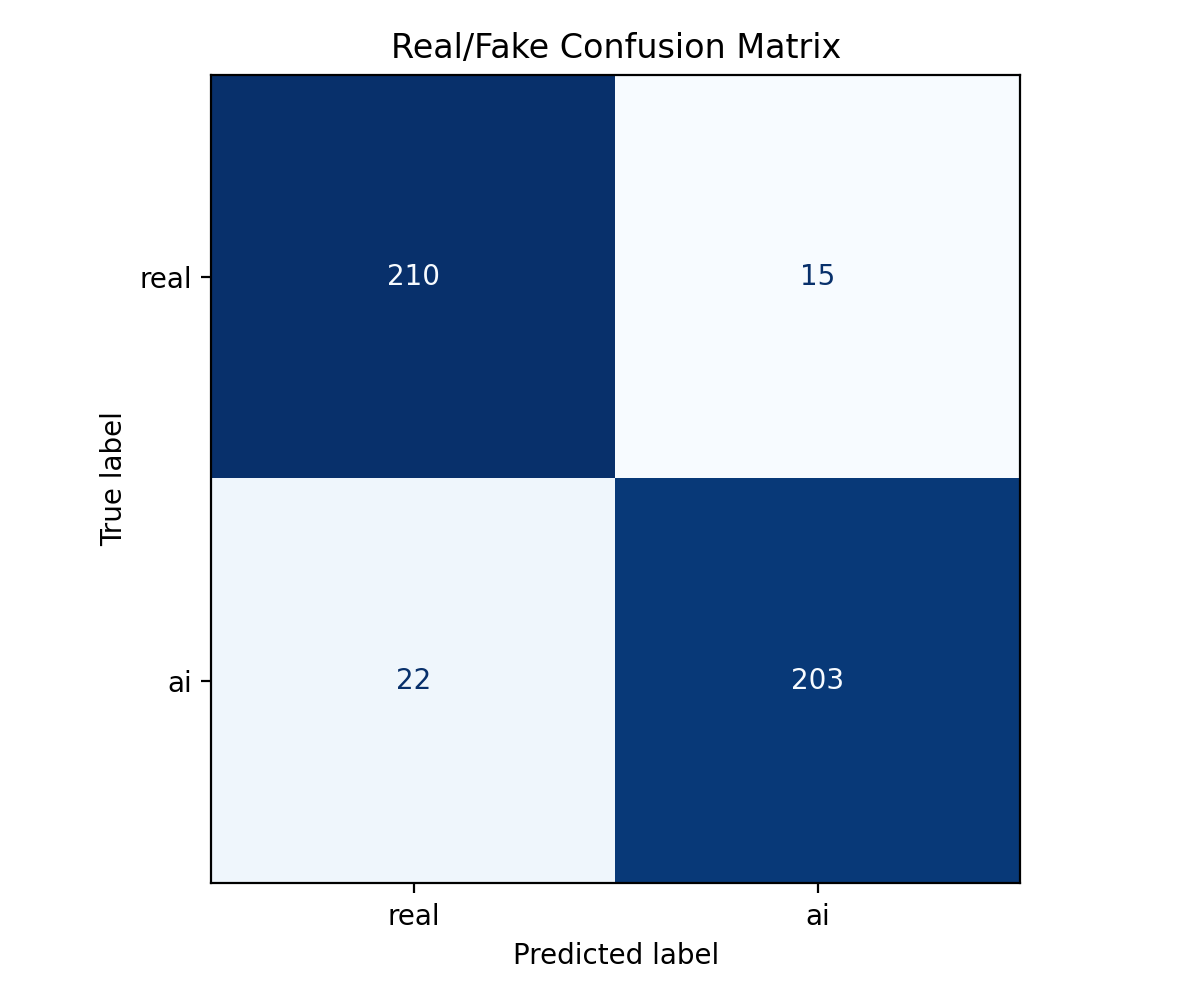

In [67]:
show_evaluation_outputs("results/rgb_fake")

### Single-task Transformation Baseline

In [46]:
# Train the transformation single-task baseline.
!python src/train_RGB.py \
  --task transform \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_transform.pt

Selected task: transform
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:39<00:00,  1.65it/s]
Validation: 100% 15/15 [00:10<00:00,  1.42it/s]
Train: {'loss': 1.0673060448964438, 'transform_acc': 0.42714285714285716}
Val:   {'loss': 0.792225516397092, 'transform_acc': 0.6288888888888889}
Val score: 0.6289
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_transform.pt

Epoch 2/10
Training: 100% 66/66 [00:39<00:00,  1.69it/s]
Validation: 100% 15/15 [00:10<00:00,  1.42it/s]
Train: {'loss': 0.6638988896778651, 'transform_acc': 0.6538095238095238}
Val:   {'loss': 0.6701960959699419, 'transform_acc': 0.7244444444444444}
Val score: 0.7244
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_transform.pt

Epoch 3/10
Training: 100% 66/66 [00:39<00:00,  1.66it/s]
Validation: 100% 15/15 [00:10<00:00,  1.42it/s]
Train: {'loss': 0.5137513318515959, 'transform_acc': 0.7547619047619047}
Val:   {'loss': 0.6046585806210836, 'transform_acc': 0.7311111111111112

In [47]:
# Evaluate the transformation single-task baseline.
!python src/evaluate_RGB.py \
  --task transform \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_transform.pt \
  --output_dir results/rgb_transform \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: transform
Using device: cuda

Evaluation results
Transform accuracy:   0.8244
Transform F1 macro:   0.8242

Saved results in:
results/rgb_transform


Evaluation metrics


,Metric,Group,Value
0,transform_accuracy,-,0.8244
1,transform_f1_macro,-,0.8242



Transformation confusion matrix


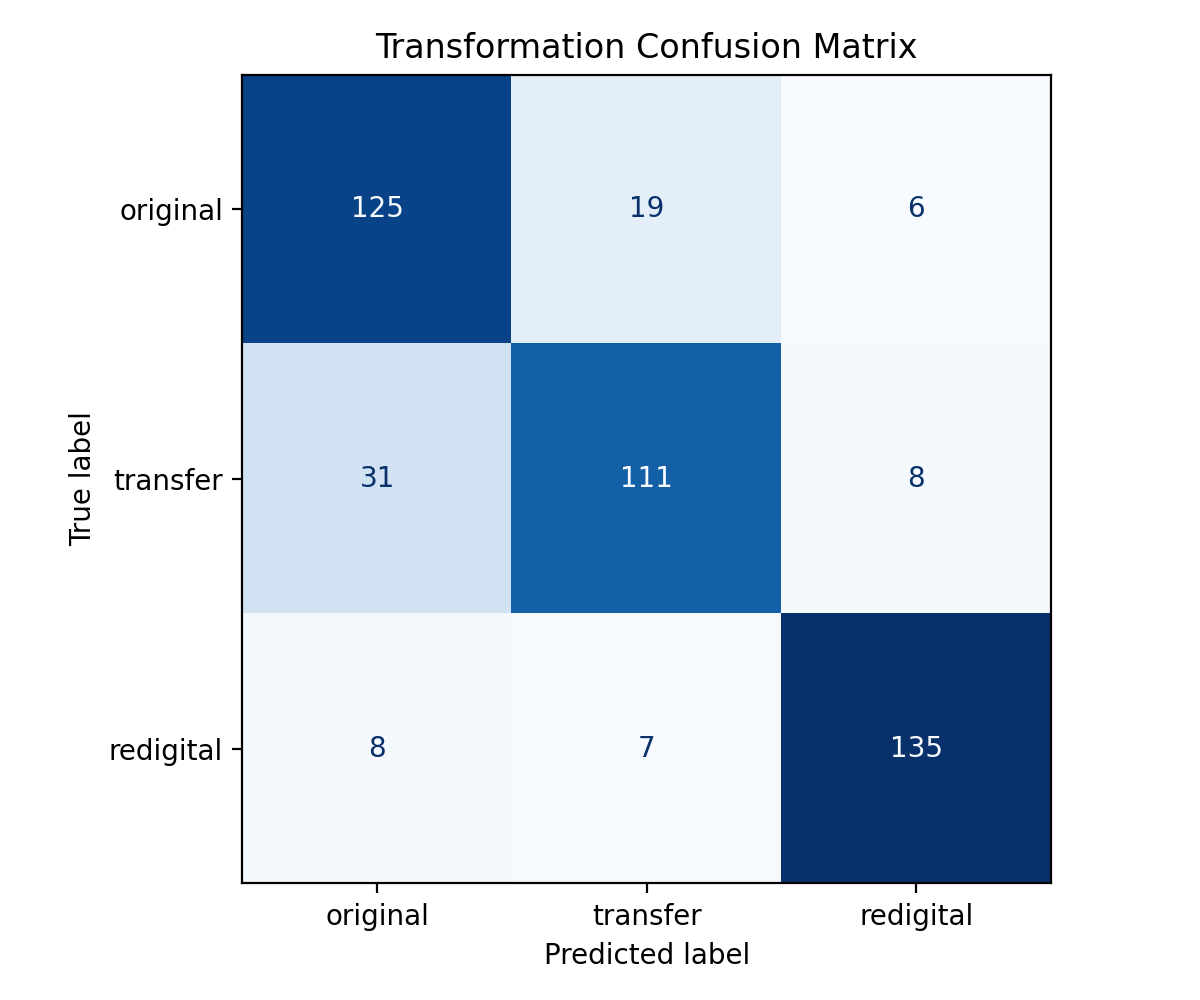

In [68]:
show_evaluation_outputs("results/rgb_transform")

### Multi-task Baseline, Manual Weights 1.0 / 1.0

In [49]:
# Train the joint RGB multi-task baseline with weights 1 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_1_1.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:09<00:00,  1.55it/s]
Train: {'loss': 1.3558013287044708, 'fake_acc': 0.8623809523809524, 'transform_acc': 0.44904761904761903}
Val:   {'loss': 1.0332122352388171, 'fake_acc': 0.9311111111111111, 'transform_acc': 0.6155555555555555}
Val score: 0.7733
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_1.pt

Epoch 2/10
Training: 100% 66/66 [00:40<00:00,  1.62it/s]
Validation: 100% 15/15 [00:10<00:00,  1.49it/s]
Train: {'loss': 0.797967152936118, 'fake_acc': 0.9757142857142858, 'transform_acc': 0.6447619047619048}
Val:   {'loss': 0.9018566020329793, 'fake_acc': 0.9066666666666666, 'transform_acc': 0.7088888888888889}
Val score: 0.8078
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_1.pt

Epoch 3/10
Training: 100% 66/66 [00:40<00:00,  1.63it/s]
Validation: 100% 15/15 [00:10<00:00,  1.42it/s]
Train: {

In [50]:
# Evaluate the joint RGB multi-task baseline with weights 1 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_1.pt \
  --output_dir results/rgb_multitask_1_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9267
Fake F1 macro:        0.9265

Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9333
  redigital: 0.9133
Transform accuracy:   0.7978
Transform F1 macro:   0.7981

Saved results in:
results/rgb_multitask_1_1


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9267
1,fake_f1_macro,-,0.9265
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9333
4,fake_accuracy_by_transform,redigital,0.9133
5,transform_accuracy,-,0.7978
6,transform_f1_macro,-,0.7981



Real/Fake confusion matrix


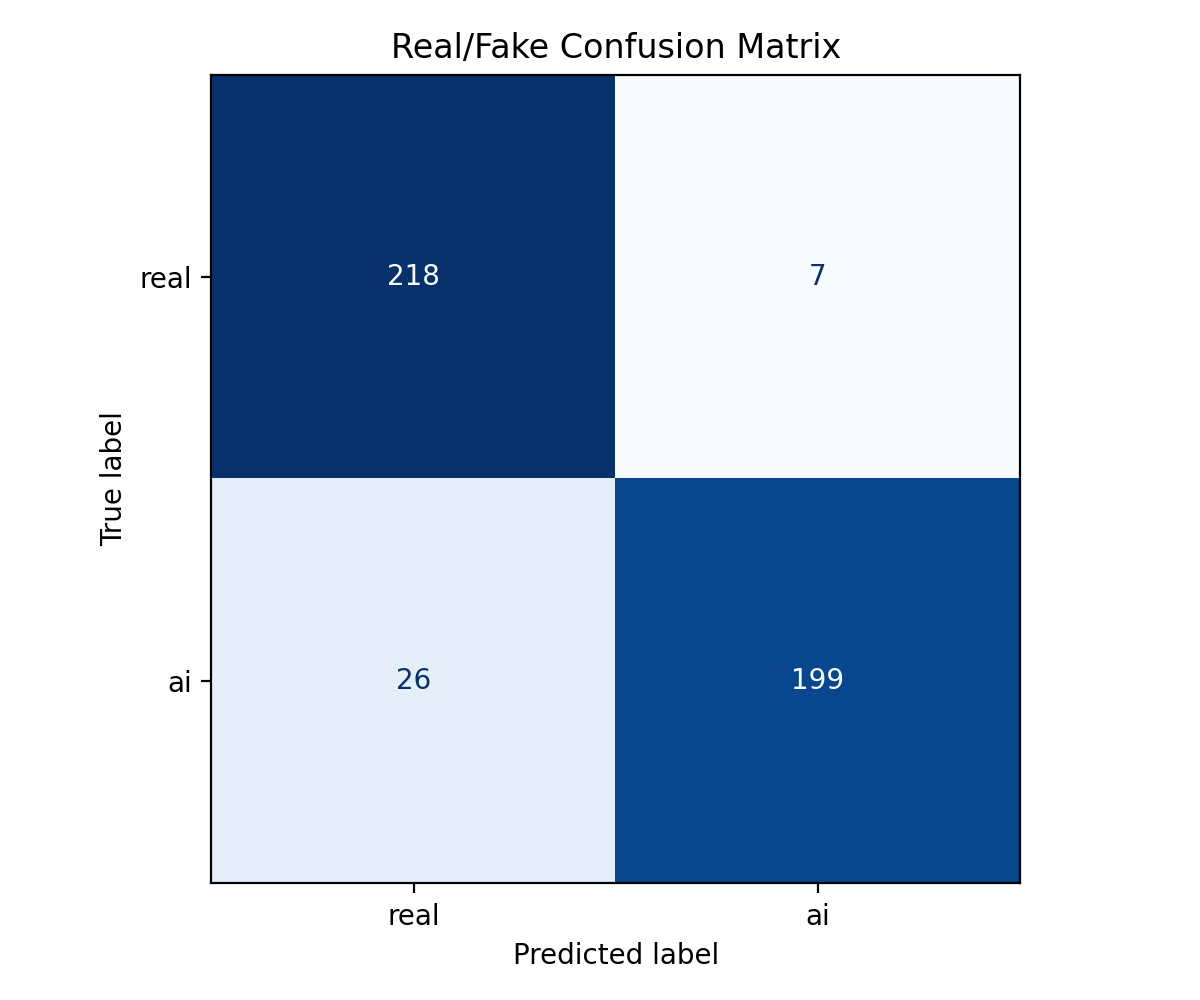


Transformation confusion matrix


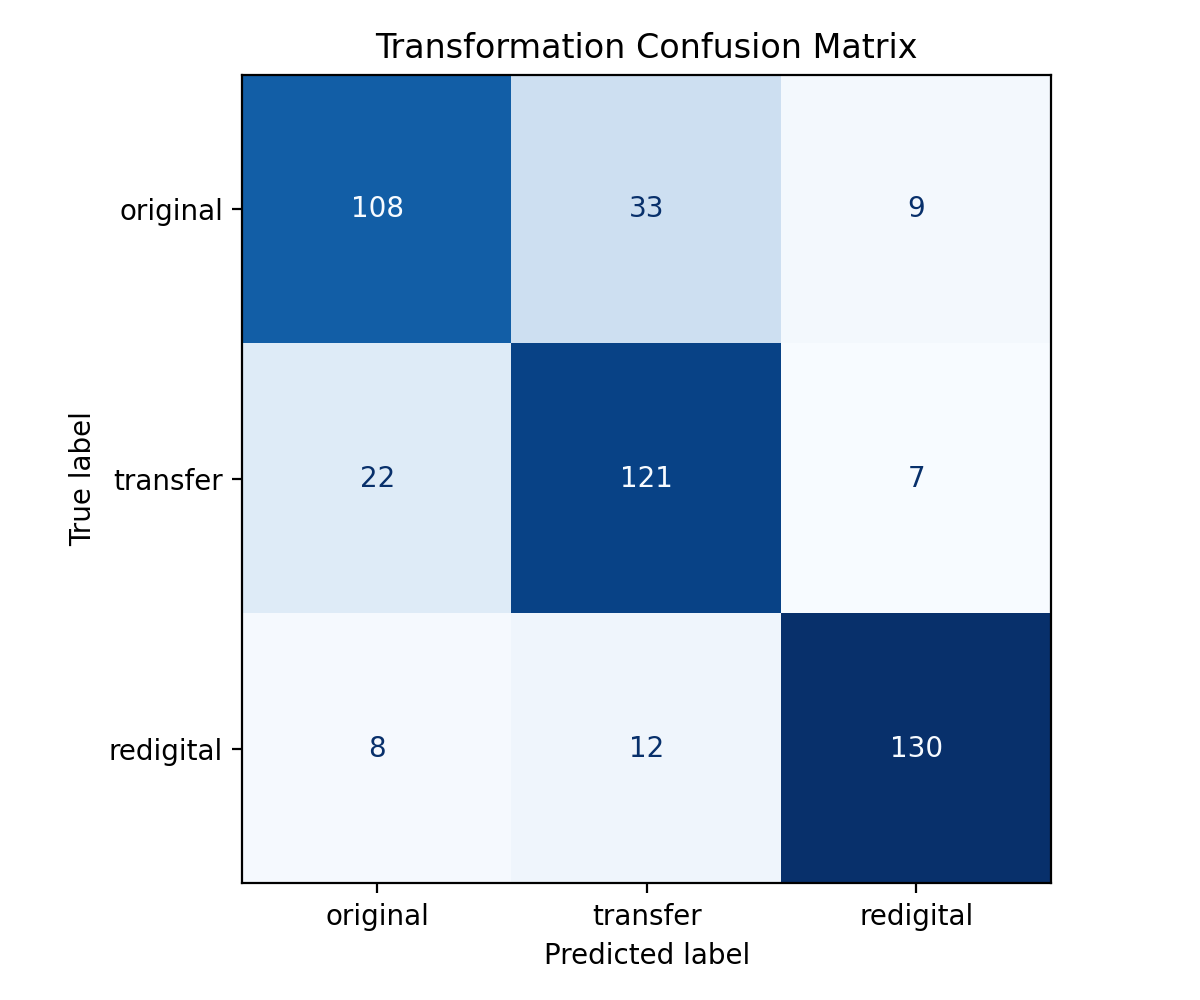

In [69]:
show_evaluation_outputs("results/rgb_multitask_1_1")

### Multi-task Baseline, Manual Weights 1.0 / 2.0

In [52]:
# Train the joint RGB multi-task baseline with weights 1 2.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 2.0 \
  --checkpoint_name best_rgb_multitask_1_2.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.43it/s]
Train: {'loss': 2.4871891164779663, 'fake_acc': 0.8285714285714286, 'transform_acc': 0.4238095238095238}
Val:   {'loss': 1.9020454671647813, 'fake_acc': 0.8888888888888888, 'transform_acc': 0.6088888888888889}
Val score: 0.7489
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_2.pt

Epoch 2/10
Training: 100% 66/66 [00:39<00:00,  1.68it/s]
Validation: 100% 15/15 [00:09<00:00,  1.55it/s]
Train: {'loss': 1.4615198982329596, 'fake_acc': 0.9528571428571428, 'transform_acc': 0.6628571428571428}
Val:   {'loss': 1.6908832671907212, 'fake_acc': 0.9044444444444445, 'transform_acc': 0.6844444444444444}
Val score: 0.7944
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_2.pt

Epoch 3/10
Training: 100% 66/66 [00:40<00:00,  1.63it/s]
Validation: 100% 15/15 [00:09<00:00,  1.60it/s]
Train: {

In [53]:
# Evaluate the joint RGB multi-task baseline with weights 1 2.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_2.pt \
  --output_dir results/rgb_multitask_1_2 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9156
Fake F1 macro:        0.9154

Fake accuracy by transformation:
  original: 0.9133
  transfer: 0.9133
  redigital: 0.9200
Transform accuracy:   0.8133
Transform F1 macro:   0.8141

Saved results in:
results/rgb_multitask_1_2


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9156
1,fake_f1_macro,-,0.9154
2,fake_accuracy_by_transform,original,0.9133
3,fake_accuracy_by_transform,transfer,0.9133
4,fake_accuracy_by_transform,redigital,0.9200
5,transform_accuracy,-,0.8133
6,transform_f1_macro,-,0.8141



Real/Fake confusion matrix


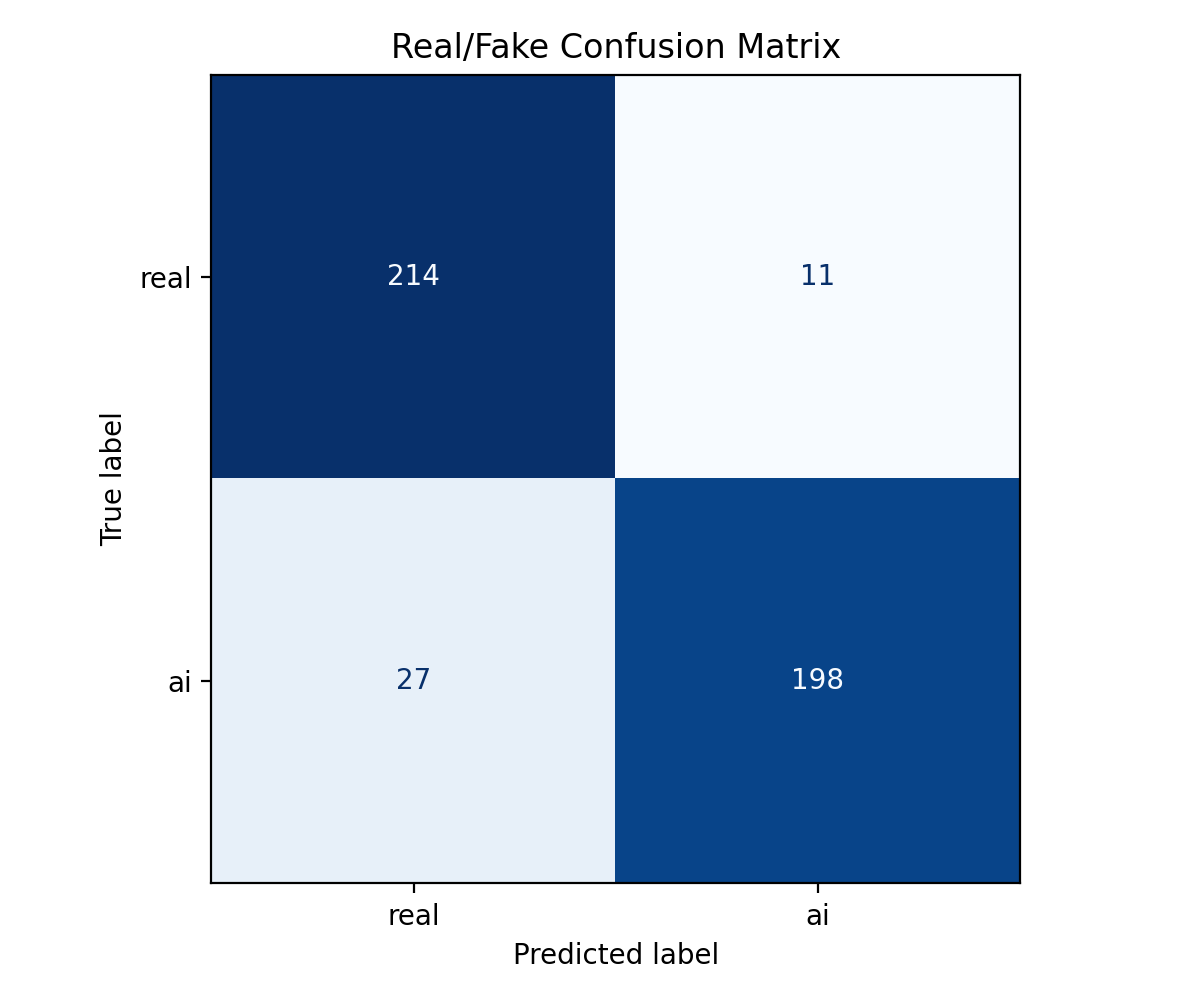


Transformation confusion matrix


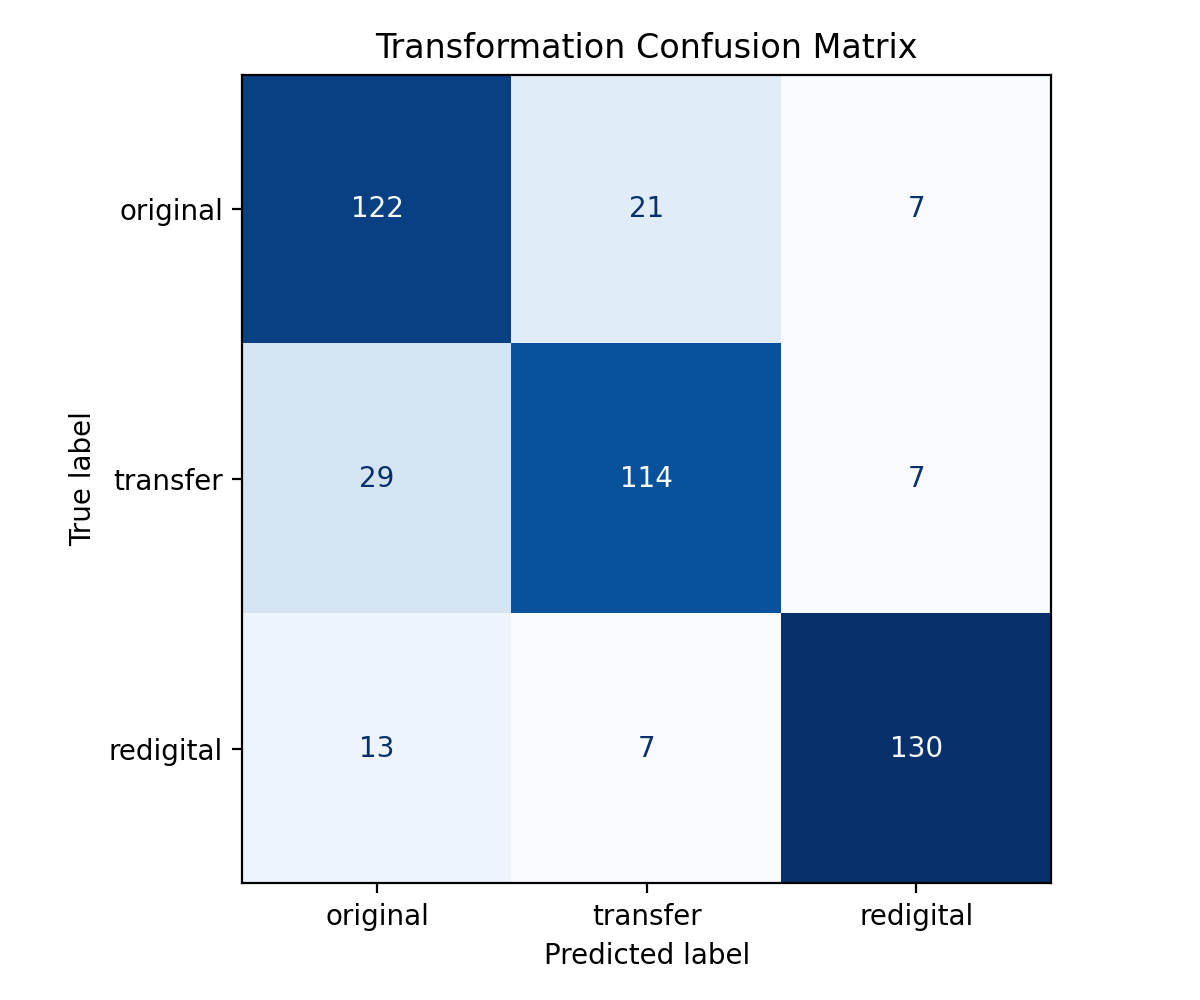

In [70]:
show_evaluation_outputs("results/rgb_multitask_1_2")

### Multi-task Baseline, Manual Weights 2.0 / 1.0

In [55]:
# Train the joint RGB multi-task baseline with weights 2 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 2.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_2_1.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.39it/s]
Train: {'loss': 1.6288477007548015, 'fake_acc': 0.8833333333333333, 'transform_acc': 0.40095238095238095}
Val:   {'loss': 1.3672414872381422, 'fake_acc': 0.8844444444444445, 'transform_acc': 0.6066666666666667}
Val score: 0.7456
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_2_1.pt

Epoch 2/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.42it/s]
Train: {'loss': 0.8467519932701474, 'fake_acc': 0.9890476190476191, 'transform_acc': 0.6195238095238095}
Val:   {'loss': 1.2436673839886982, 'fake_acc': 0.8977777777777778, 'transform_acc': 0.6733333333333333}
Val score: 0.7856
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_2_1.pt

Epoch 3/10
Training: 100% 66/66 [00:40<00:00,  1.63it/s]
Validation: 100% 15/15 [00:10<00:00,  1.38it/s]
Train: 

In [56]:
# Evaluate the joint RGB multi-task baseline with weights 2 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_2_1.pt \
  --output_dir results/rgb_multitask_2_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9156
Fake F1 macro:        0.9154

Fake accuracy by transformation:
  original: 0.9133
  transfer: 0.9133
  redigital: 0.9200
Transform accuracy:   0.7956
Transform F1 macro:   0.7952

Saved results in:
results/rgb_multitask_2_1


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9156
1,fake_f1_macro,-,0.9154
2,fake_accuracy_by_transform,original,0.9133
3,fake_accuracy_by_transform,transfer,0.9133
4,fake_accuracy_by_transform,redigital,0.9200
5,transform_accuracy,-,0.7956
6,transform_f1_macro,-,0.7952



Real/Fake confusion matrix


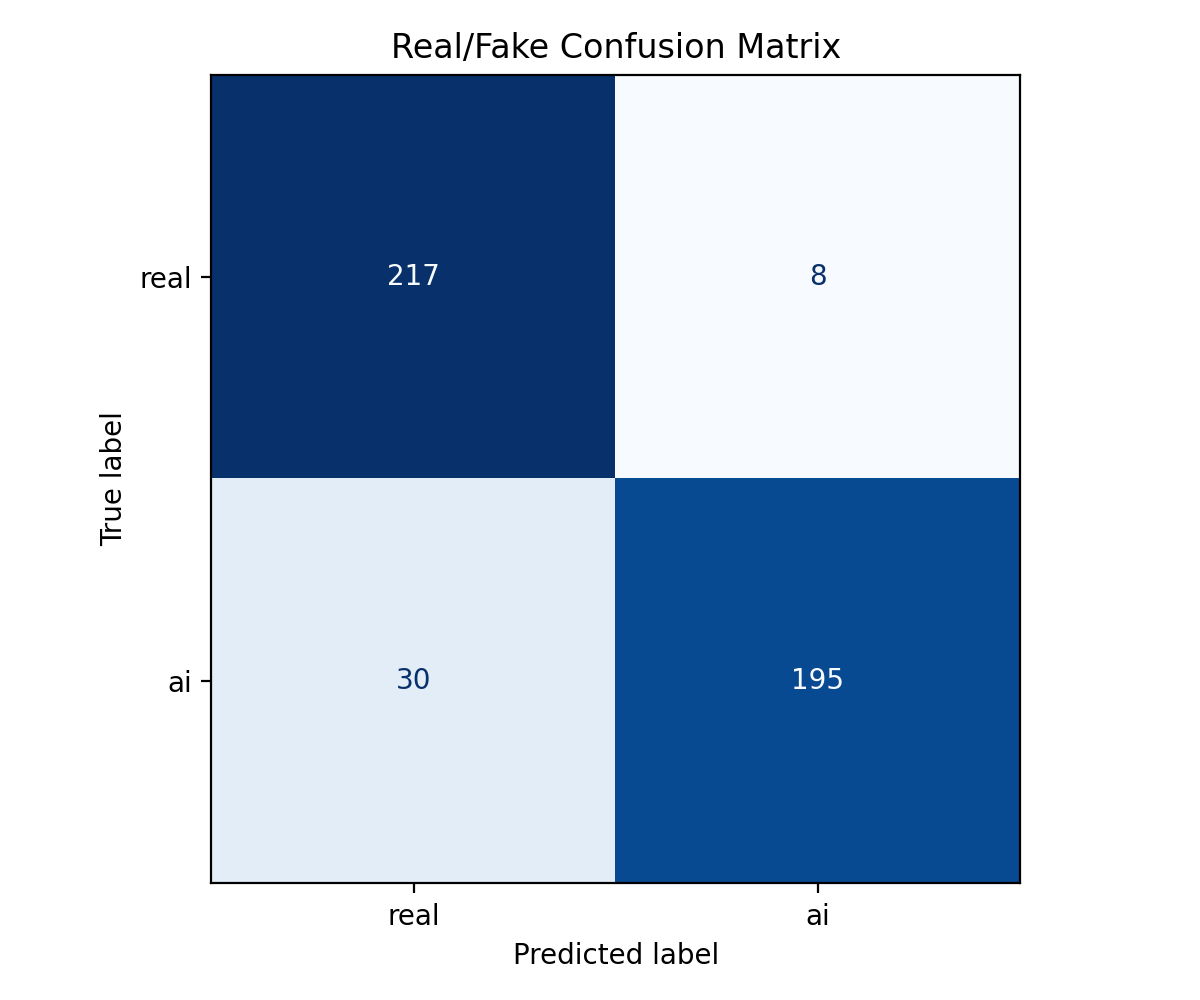


Transformation confusion matrix


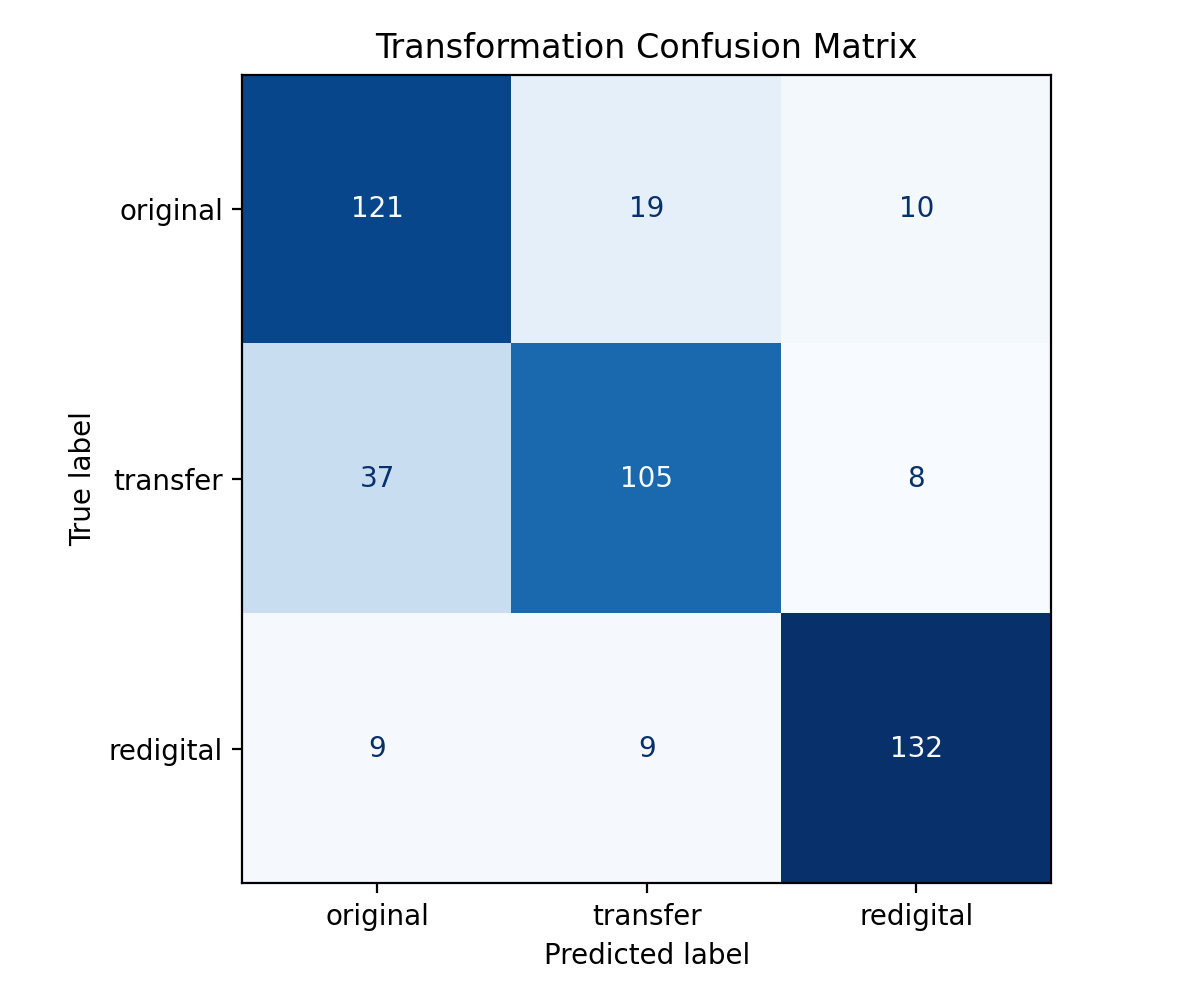

In [71]:
show_evaluation_outputs("results/rgb_multitask_2_1")

### Multi-task Baseline, Learned Uncertainty Weighting

In [58]:
# Train the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/train_RGB.py \
  --task multitask \
  --loss_weighting learned \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_multitask_learned_weights.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.63it/s]
Validation: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: {'loss': 1.3649481098992484, 'fake_acc': 0.8652380952380953, 'transform_acc': 0.44904761904761903, 'weight_fake': 1.003433361197963, 'weight_transform': 0.9978829035253236}
Val:   {'loss': 1.039556327925788, 'fake_acc': 0.9044444444444445, 'transform_acc': 0.6133333333333333, 'weight_fake': 1.0072288513183594, 'weight_transform': 0.9970179796218872}
Learned loss weights (train): fake=1.0034, transform=0.9979
Learned loss weights (val):   fake=1.0072, transform=0.9970
Val score: 0.7589
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_learned_weights.pt

Epoch 2/10
Training: 100% 66/66 [00:40<00:00,  1.65it/s]
Validation: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: {'loss': 0.742016871429625, 'fake_acc': 0.979047619047619, 'transform_acc': 0.660952380952381, 'weight_fake': 1.0110185778502263, 'weight_tra

In [59]:
# Evaluate the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_learned_weights.pt \
  --output_dir results/rgb_multitask_learned_weights \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9200
Fake F1 macro:        0.9199

Fake accuracy by transformation:
  original: 0.9200
  transfer: 0.9200
  redigital: 0.9200
Transform accuracy:   0.7800
Transform F1 macro:   0.7807

Saved results in:
results/rgb_multitask_learned_weights


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9200
1,fake_f1_macro,-,0.9199
2,fake_accuracy_by_transform,original,0.9200
3,fake_accuracy_by_transform,transfer,0.9200
4,fake_accuracy_by_transform,redigital,0.9200
5,transform_accuracy,-,0.7800
6,transform_f1_macro,-,0.7807



Real/Fake confusion matrix


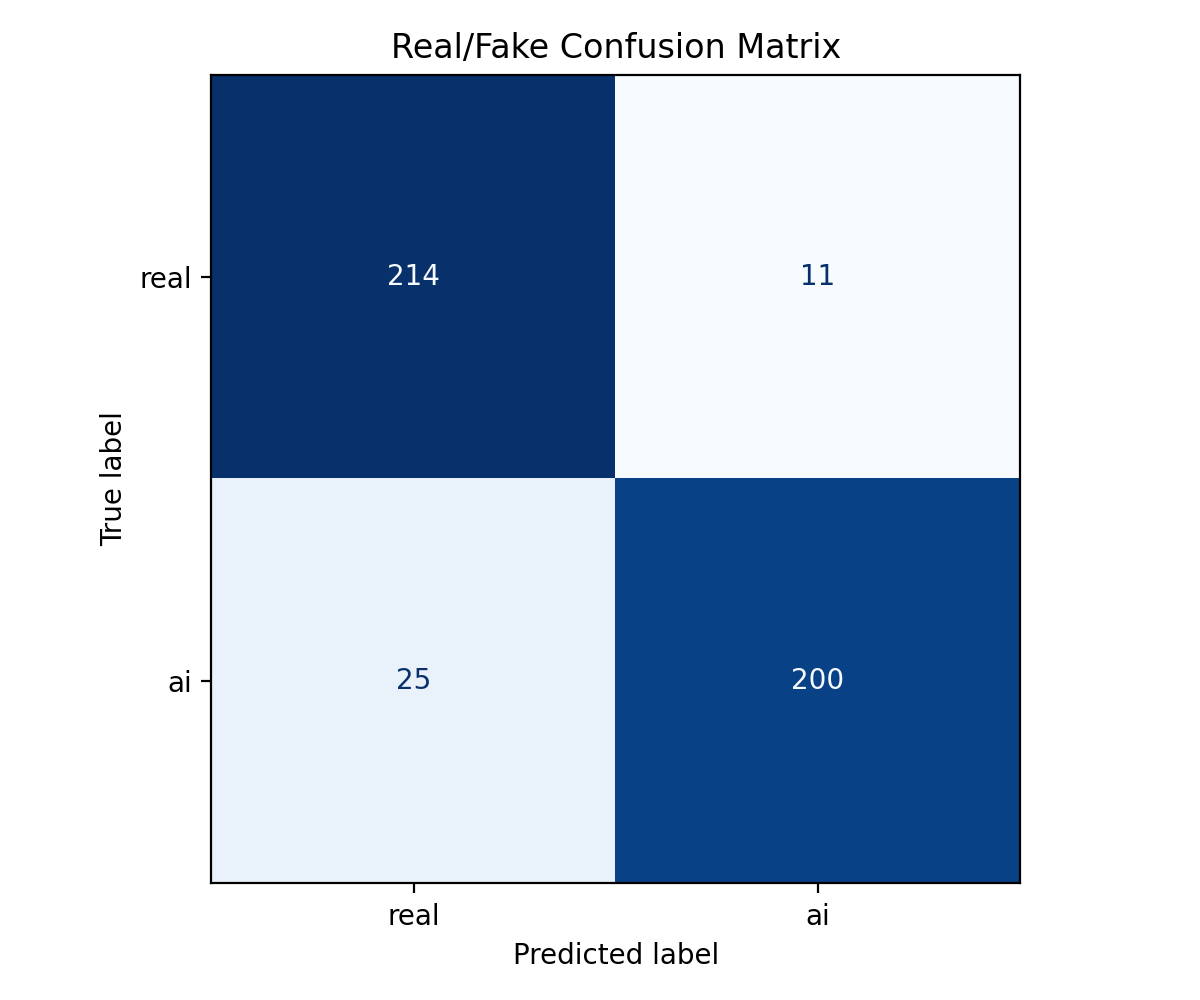


Transformation confusion matrix


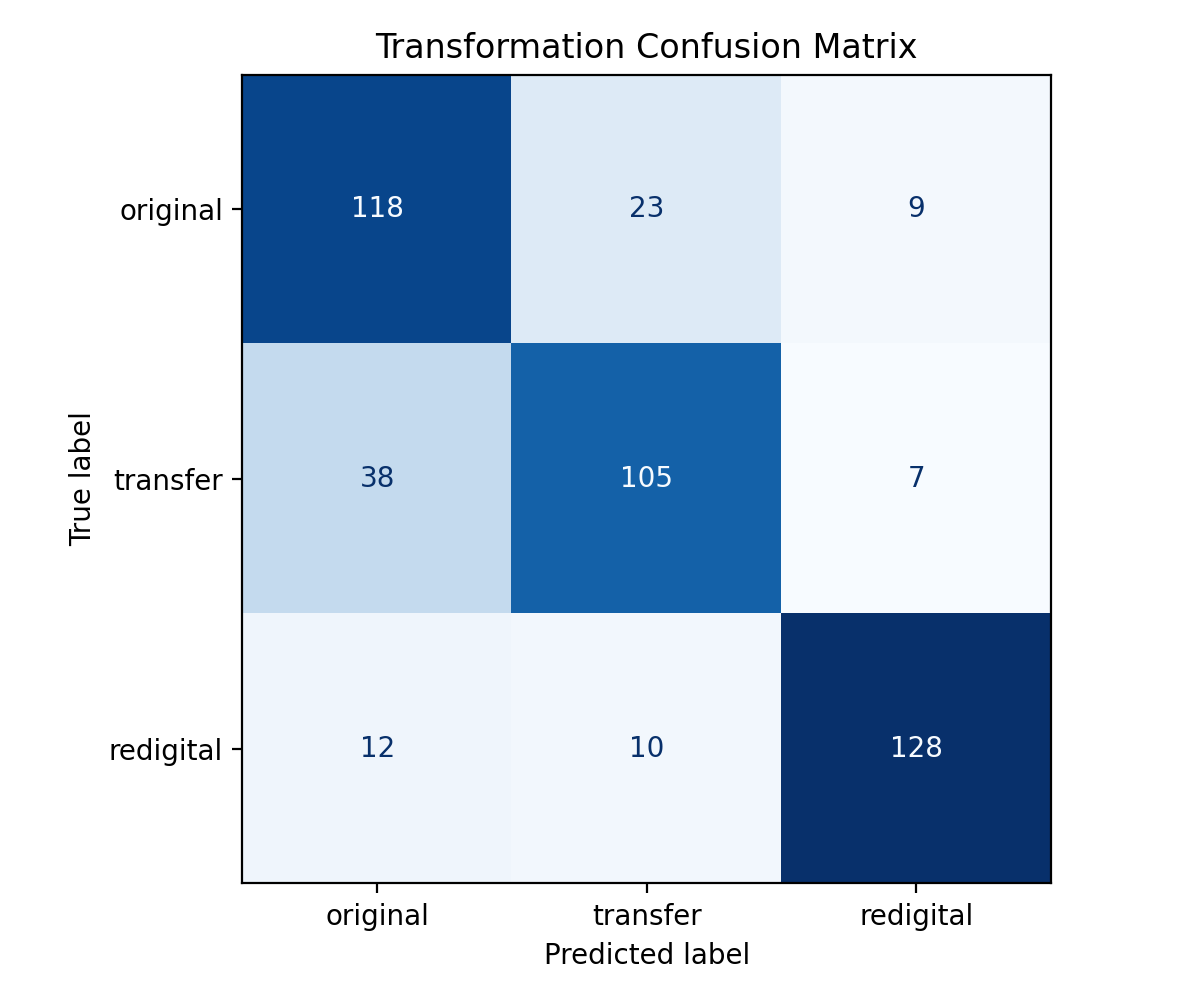

In [72]:
show_evaluation_outputs("results/rgb_multitask_learned_weights")

## Results Comparison and Ablation Study

In [61]:
results = {
    "RGB fake-only": "results/rgb_fake/metrics.json",
    "RGB transform-only": "results/rgb_transform/metrics.json",
    "RGB multitask 1-1": "results/rgb_multitask_1_1/metrics.json",
    "RGB multitask 1-2": "results/rgb_multitask_1_2/metrics.json",
    "RGB multitask 2-1": "results/rgb_multitask_2_1/metrics.json",
    "RGB multitask learned": "results/rgb_multitask_learned_weights/metrics.json",
}

rows = []

for model_name, metrics_path in results.items():
    metrics_path = Path(metrics_path)

    if not metrics_path.exists():
        print(f"Missing file: {metrics_path}")
        continue

    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    rows.append({
        "model": model_name,
        "fake_accuracy": metrics.get("fake_accuracy"),
        "fake_f1_macro": metrics.get("fake_f1_macro"),
        "transform_accuracy": metrics.get("transform_accuracy"),
        "transform_f1_macro": metrics.get("transform_f1_macro"),
        "fake_acc_original": metrics.get("fake_accuracy_by_transform", {}).get("original"),
        "fake_acc_transfer": metrics.get("fake_accuracy_by_transform", {}).get("transfer"),
        "fake_acc_redigital": metrics.get("fake_accuracy_by_transform", {}).get("redigital"),
    })

comparison_df = pd.DataFrame(rows)
comparison_df.sort_values(
    by=["fake_accuracy", "transform_accuracy"],
    ascending=False
)

,model,fake_accuracy,fake_f1_macro,transform_accuracy,transform_f1_macro,fake_acc_original,fake_acc_transfer,fake_acc_redigital
2,RGB multitask 1-1,0.926667,0.926536,0.797778,0.798067,0.933333,0.933333,0.913333
5,RGB multitask learned,0.920000,0.919922,0.780000,0.780684,0.920000,0.920000,0.920000
0,RGB fake-only,0.917778,0.917758,NaN,NaN,0.920000,0.926667,0.906667
3,RGB multitask 1-2,0.915556,0.915449,0.813333,0.814082,0.913333,0.913333,0.920000
4,RGB multitask 2-1,0.915556,0.915353,0.795556,0.795152,0.913333,0.913333,0.920000
1,RGB transform-only,NaN,NaN,0.824444,0.824236,NaN,NaN,NaN


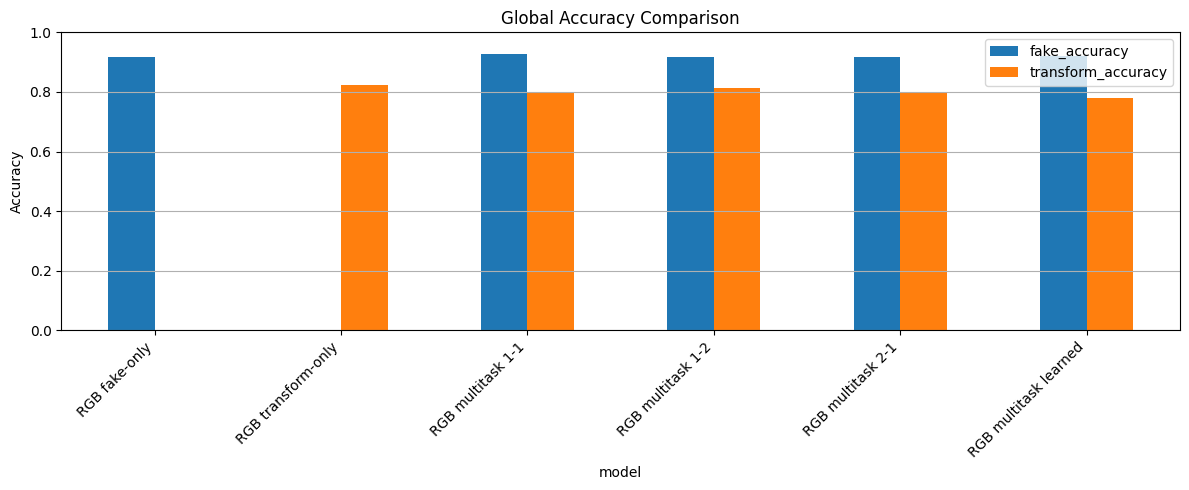

In [62]:
# Global Accuracy Comparison

plot_df = comparison_df.set_index("model")

plot_df[["fake_accuracy", "transform_accuracy"]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Global Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

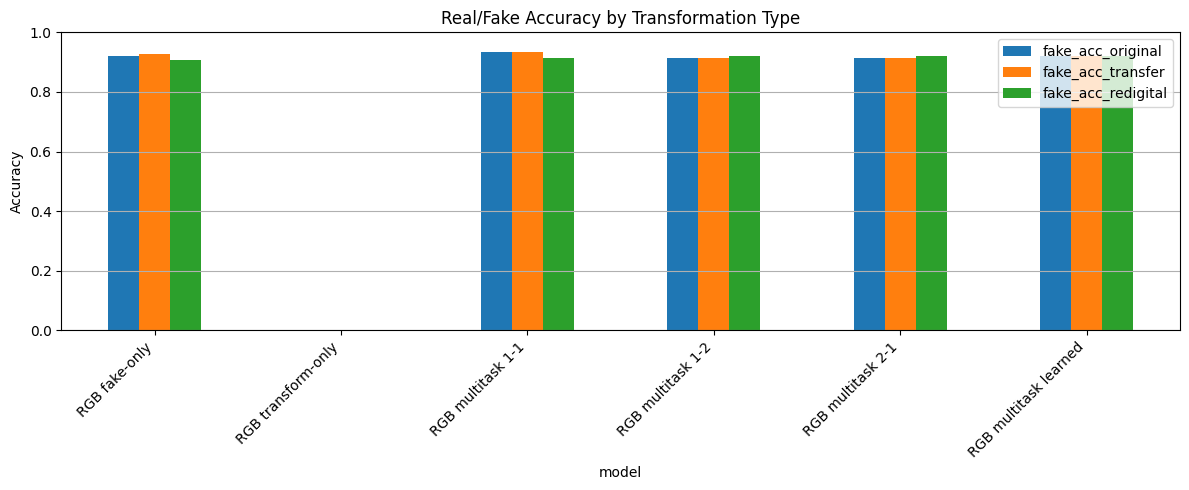

In [63]:
# Real/Fake Accuracy by Transformation Type
plot_df[[
    "fake_acc_original",
    "fake_acc_transfer",
    "fake_acc_redigital",
]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Real/Fake Accuracy by Transformation Type")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#DEPTH

In [ ]:
!find /content -name "real_006970.jpg"

##Depth map generation

###first small debug

In [ ]:
!python src/generate_depth_map.py \
  --csv_paths {TRAIN_CSV} {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --model_type MiDaS_small \
  --max_images 5

###full depth map generation

In [ ]:
!python src/generate_depth_map.py \
  --csv_paths {TRAIN_CSV} {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --model_type MiDaS_small

##copy of depth maph in local so colab doesn't need to go on drive every time

In [ ]:
DRIVE_DEPTH_ROOT = "/content/drive/MyDrive/CV_Project/depth_maps"
LOCAL_DEPTH_ROOT = "/content/depth_maps"

!mkdir -p "{LOCAL_DEPTH_ROOT}"
!rsync -a --info=progress2 "{DRIVE_DEPTH_ROOT}/" "{LOCAL_DEPTH_ROOT}/"

DEPTH_ROOT = LOCAL_DEPTH_ROOT

print("Depth maps will be loaded from:", DEPTH_ROOT)

##First try with depth only

In [ ]:
CHECKPOINT_NAME = "best_depth_only.pt"

!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name {CHECKPOINT_NAME} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --lambda_fake {LAMBDA_FAKE} \
  --lambda_transform {LAMBDA_TRANSFORM} \
  --no_edge

##Second try with also edge consistency

In [ ]:
CHECKPOINT_NAME = "best_depth_full.pt"
!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name {CHECKPOINT_NAME} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --lambda_fake {LAMBDA_FAKE} \
  --lambda_transform {LAMBDA_TRANSFORM}

The edge-consistency branch introduces additional geometric information, but also increases model complexity. This leads to mild overfitting and a small decrease in real/fake validation accuracy, although transformation classification slightly improves.
We should use only depth without edge